In [1]:
from google.colab import drive
drive.mount('/content/drive')
#install missing libraries
!pip install mplfinance plotly kaleido --quiet
import os
#setting base project path
BASE = '/content/drive/MyDrive/cryptocurrency-analysis'
RAW  = os.path.join(BASE, 'data/raw')
PROC = os.path.join(BASE, 'data/processed')
FIGS = os.path.join(BASE, 'outputs/figures')

for path in [PROC, FIGS]:
    os.makedirs(path, exist_ok=True)

print("Paths ready.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.9 MB/s eta 0:00:00
Paths ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates#to handle date formatting
import seaborn as sns
import mplfinance as mpf#for financial charts
import plotly.graph_objects as go#interactive graphs
from statsmodels.tsa.seasonal import seasonal_decompose#time series analysis
import warnings

warnings.filterwarnings('ignore')#hide warning msgs
sns.set_theme(style='darkgrid')#set seaborn theme
plt.rcParams['figure.dpi'] = 130#set resolution of graphs

In [3]:
#list all csvs in raw folder
csv_files = [f for f in os.listdir(RAW) if f.endswith('.csv')]
print(f"Found {len(csv_files)} coin files: {csv_files}\n")

#Load and tag each coin
def load_coin(filename):
    df = pd.read_csv(os.path.join(RAW, filename), parse_dates=['Date'])
    coin_name = filename.replace('coin_', '').replace('.csv', '')#extract coin name from file name
    df['Coin'] = coin_name#new col coin
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

all_coins = pd.concat([load_coin(f) for f in csv_files], ignore_index=True)#combine all coin datasets

print(all_coins.head())
print(f"\nShape: {all_coins.shape}")
print(f"\nDate range: {all_coins['Date'].min()} → {all_coins['Date'].max()}")
print(f"\nMissing values:\n{all_coins.isnull().sum()}")

Found 23 coin files: ['coin_NEM.csv', 'coin_Tether.csv', 'coin_Ethereum.csv', 'coin_Bitcoin.csv', 'coin_Litecoin.csv', 'coin_EOS.csv', 'coin_Dogecoin.csv', 'coin_XRP.csv', 'coin_Uniswap.csv', 'coin_Aave.csv', 'coin_Stellar.csv', 'coin_Monero.csv', 'coin_Polkadot.csv', 'coin_BinanceCoin.csv', 'coin_Cardano.csv', 'coin_WrappedBitcoin.csv', 'coin_Iota.csv', 'coin_CryptocomCoin.csv', 'coin_Cosmos.csv', 'coin_USDCoin.csv', 'coin_ChainLink.csv', 'coin_Tron.csv', 'coin_Solana.csv']

   SNo Name Symbol                Date      High       Low      Open  \
0    1  NEM    XEM 2015-04-02 23:59:59  0.000323  0.000227  0.000242   
1    2  NEM    XEM 2015-04-03 23:59:59  0.000330  0.000291  0.000309   
2    3  NEM    XEM 2015-04-04 23:59:59  0.000318  0.000251  0.000310   
3    4  NEM    XEM 2015-04-05 23:59:59  0.000283  0.000218  0.000272   
4    5  NEM    XEM 2015-04-06 23:59:59  0.000299  0.000229  0.000232   

      Close        Volume     Marketcap Coin  
0  0.000314  28549.400391  2.823534e+06

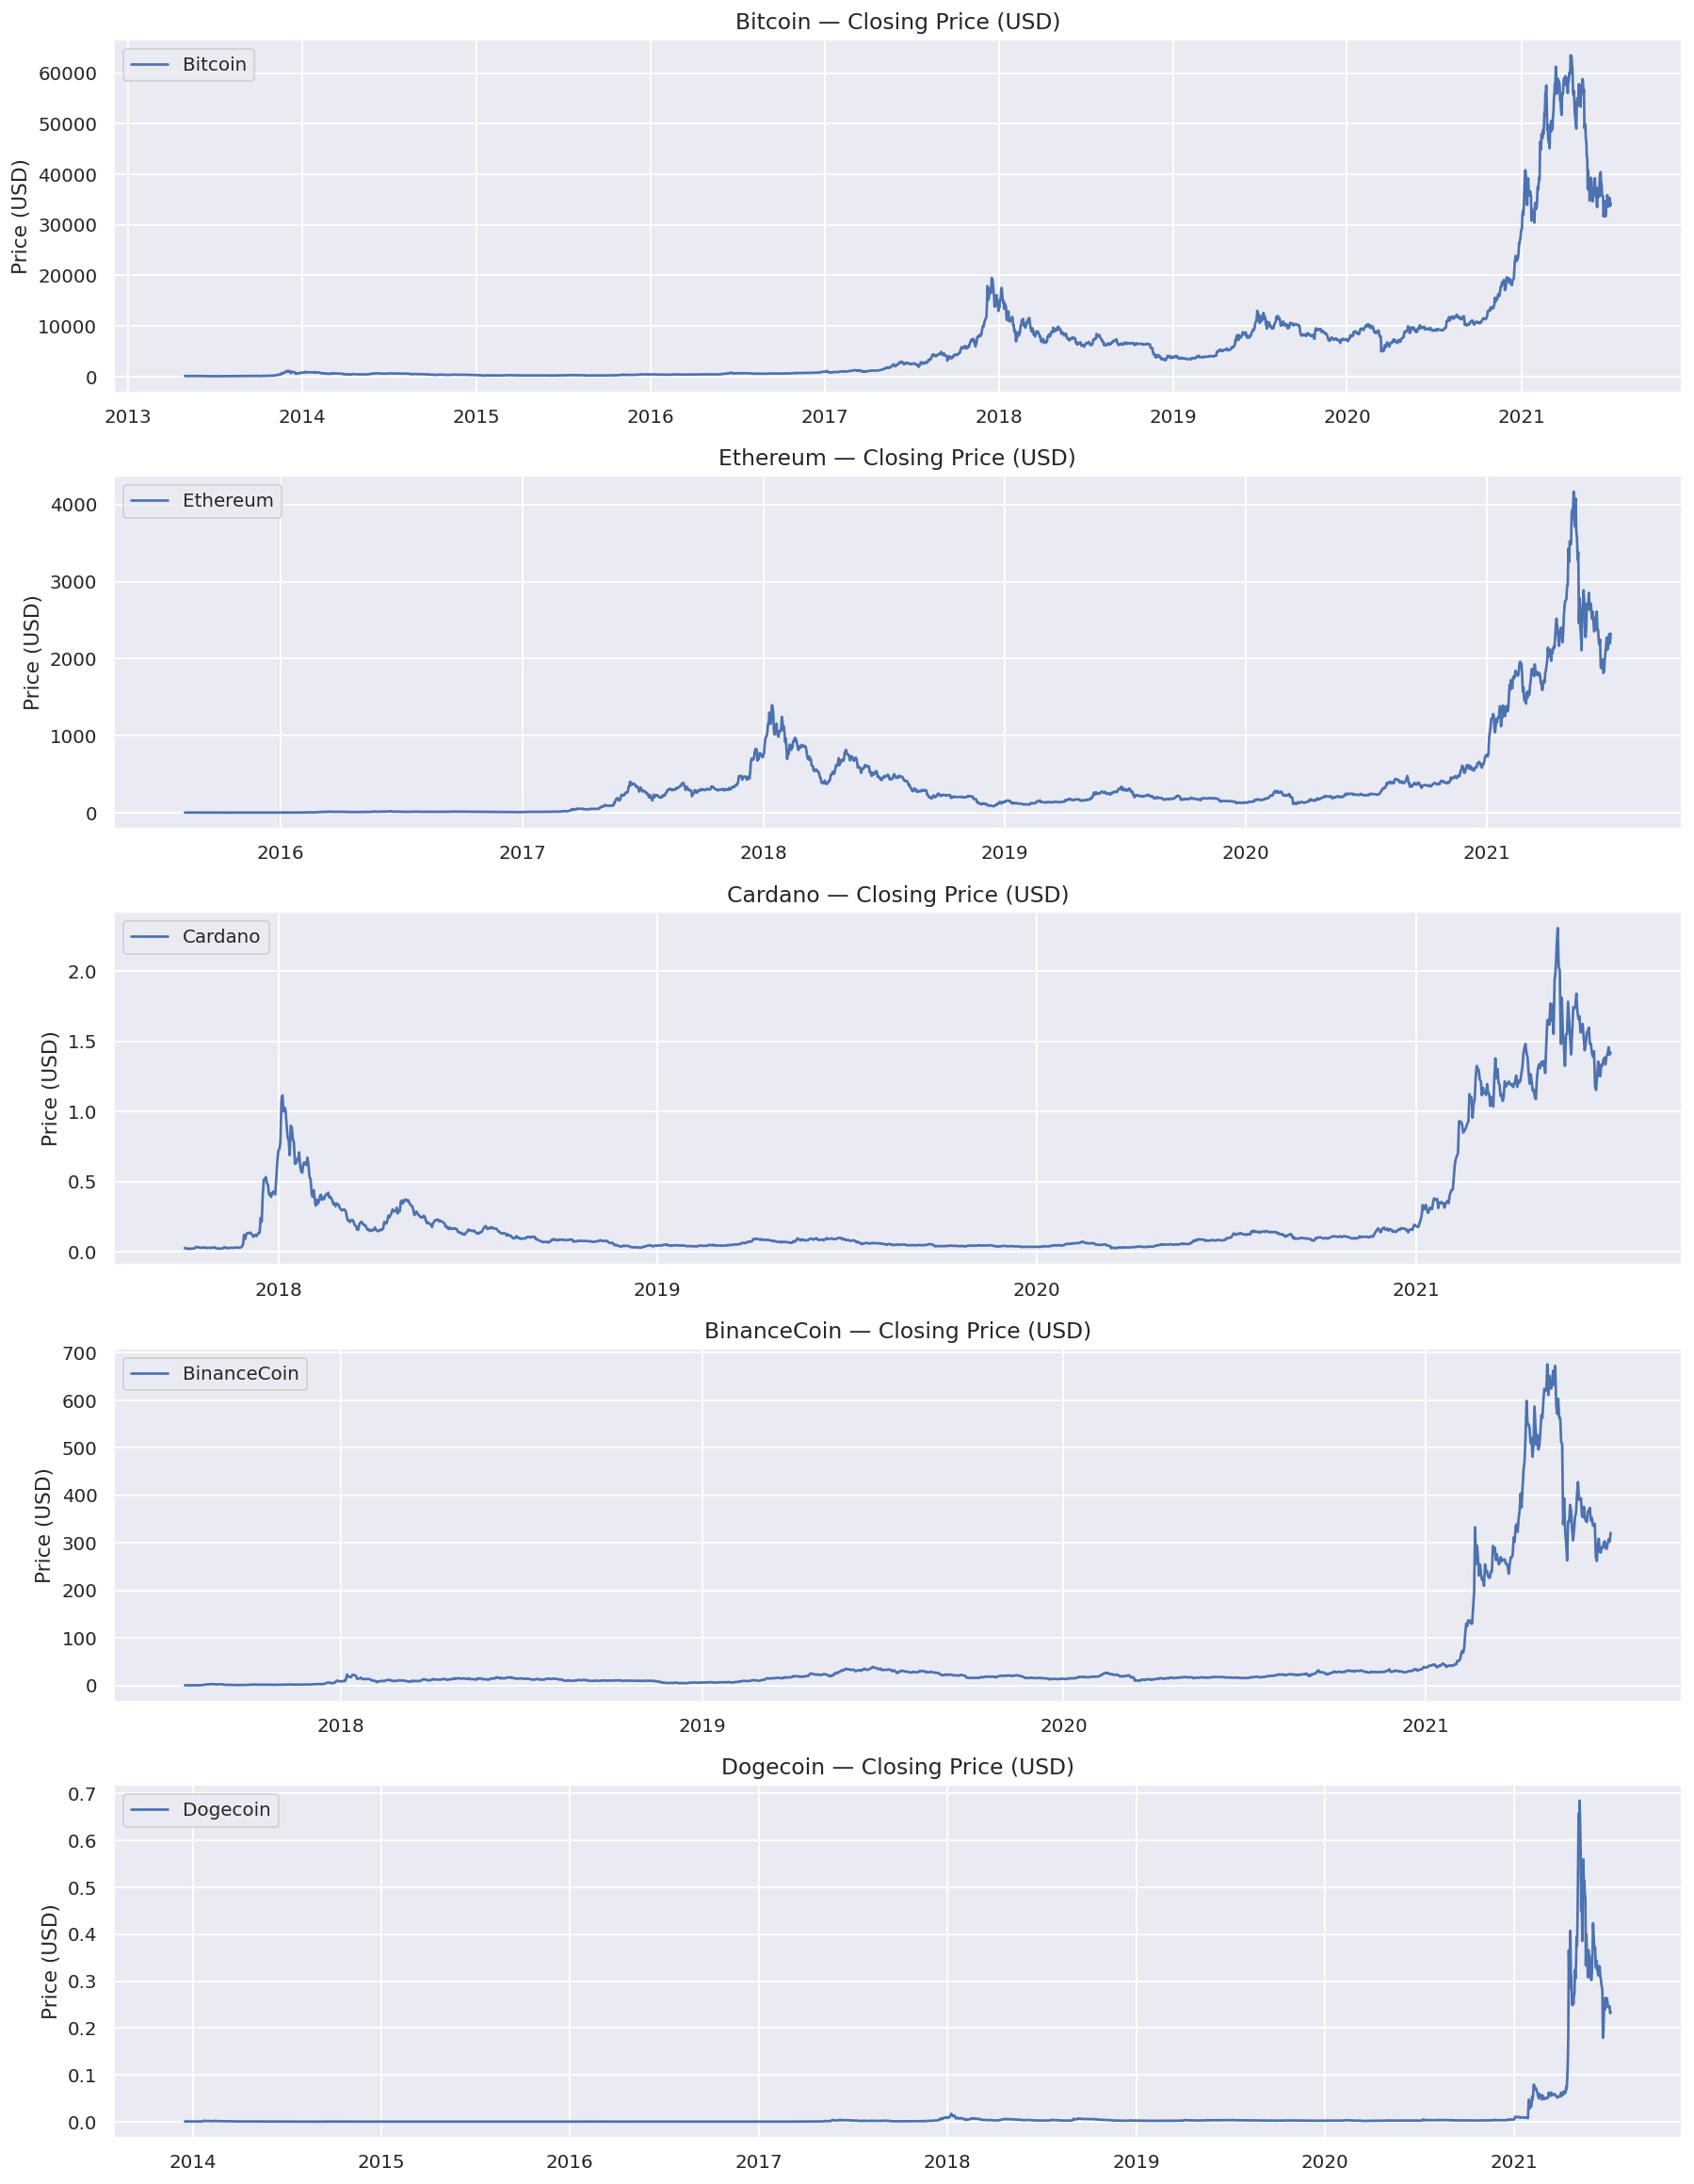

In [5]:
coins_to_plot = ['Bitcoin', 'Ethereum', 'Cardano', 'BinanceCoin', 'Dogecoin']
fig, axes = plt.subplots(len(coins_to_plot), 1, figsize=(14, 18), sharex=False)#creating subplots

for ax, coin in zip(axes, coins_to_plot):
    df = all_coins[all_coins['Coin'] == coin]
    if df.empty:
        print(f"{coin} not found, skipping.")
        continue
    ax.plot(df['Date'], df['Close'], linewidth=1.5, label=coin)
    ax.set_title(f'{coin} — Closing Price (USD)', fontsize=13)
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))#shows yearwise ticks for x axis
    ax.legend()

plt.tight_layout()
plt.show()

In [6]:
plt.savefig(os.path.join(FIGS, 'price_trends_all_coins.png'))
print("Saved: price trends")

Saved: price trends


<Figure size 832x624 with 0 Axes>

In [8]:
#candlestick chart for bitcoin(last 6 months)
'''each candle shows open,close,high and low price'''
btc = all_coins[all_coins['Coin'] == 'Bitcoin'].copy()
btc.set_index('Date', inplace=True)

# Last 180 days
btc_recent = btc[['Open', 'High', 'Low', 'Close', 'Volume']].last('180D')#selects last 180 days

mpf.plot(
    btc_recent,
    type='candle',
    style='charles',
    title='Bitcoin — Candlestick Chart (Last 6 Months)',
    ylabel='Price (USD)',
    volume=True,
    mav=(7, 21),           # 7-day and 21-day moving averages
    figsize=(14, 7),
    savefig=os.path.join(FIGS, 'obj3_candlestick_btc.png')
)
print("Saved: BTC candlestick")

Saved: BTC candlestick


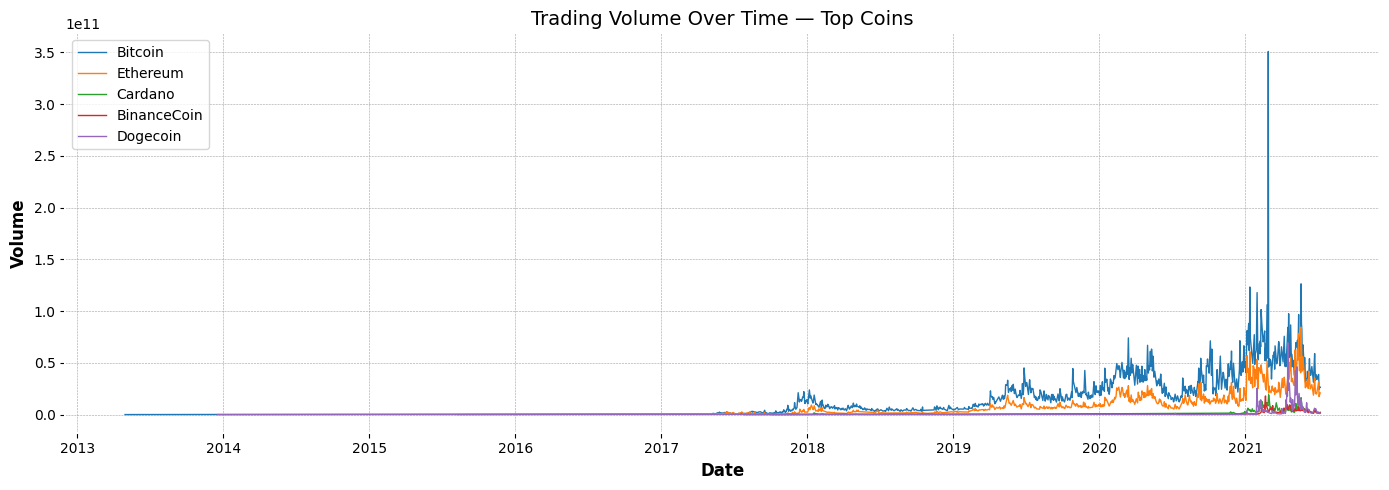

Saved: volume comparison


In [10]:
#trading value comparison
fig, ax = plt.subplots(figsize=(14, 5))

for coin in coins_to_plot:
    df = all_coins[all_coins['Coin'] == coin]
    if df.empty:
        continue
    ax.plot(df['Date'], df['Volume'], label=coin, linewidth=1)

ax.set_title('Trading Volume Over Time — Top Coins', fontsize=14)
ax.set_ylabel('Volume')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'volume_comparison.png'))
plt.show()
print("Saved: volume comparison")

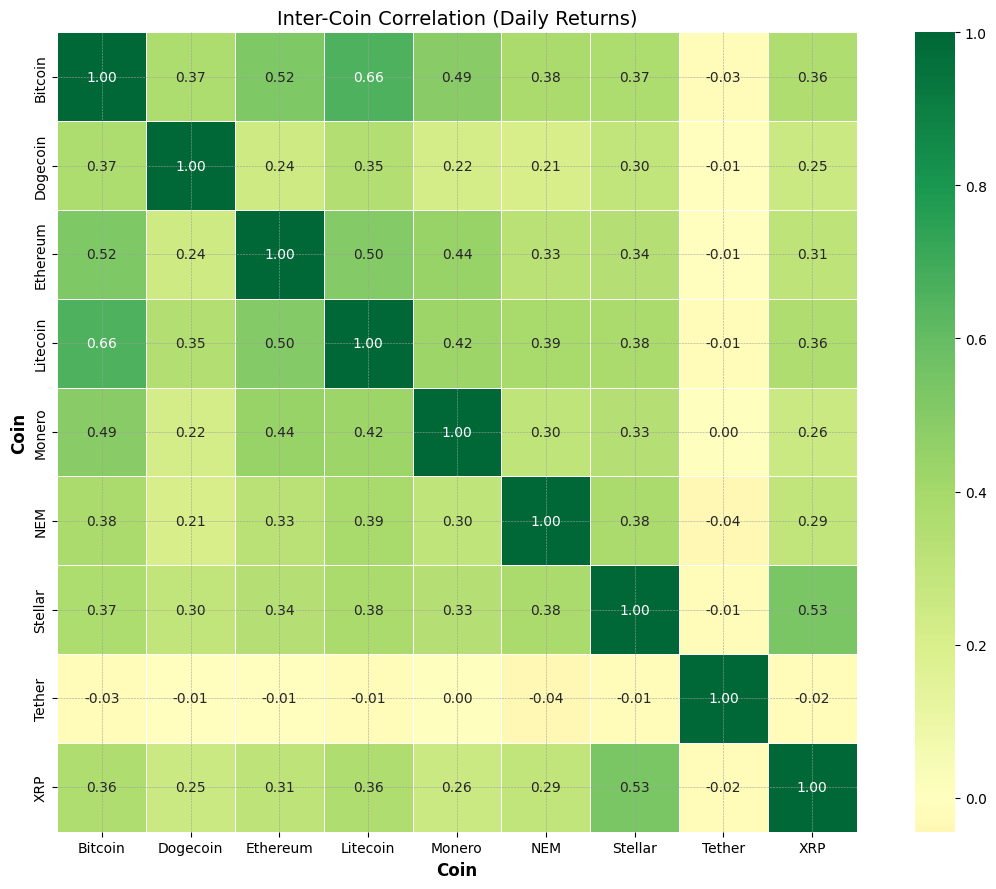

Saved: correlation heatmap


In [12]:
#intercoin correlation heatmap
#Pivot to get Close price per coin per date
pivot = all_coins.pivot_table(index='Date', columns='Coin', values='Close')#new format of data
pivot.dropna(axis=1, thresh=int(0.7 * len(pivot)), inplace=True)  # keep coins with 70%+ data

corr = pivot.pct_change().corr()  # correlation of daily returns, not raw price

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Inter-Coin Correlation (Daily Returns)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'obj3_heatmap_correlation.png'))
plt.show()
print("Saved: correlation heatmap")

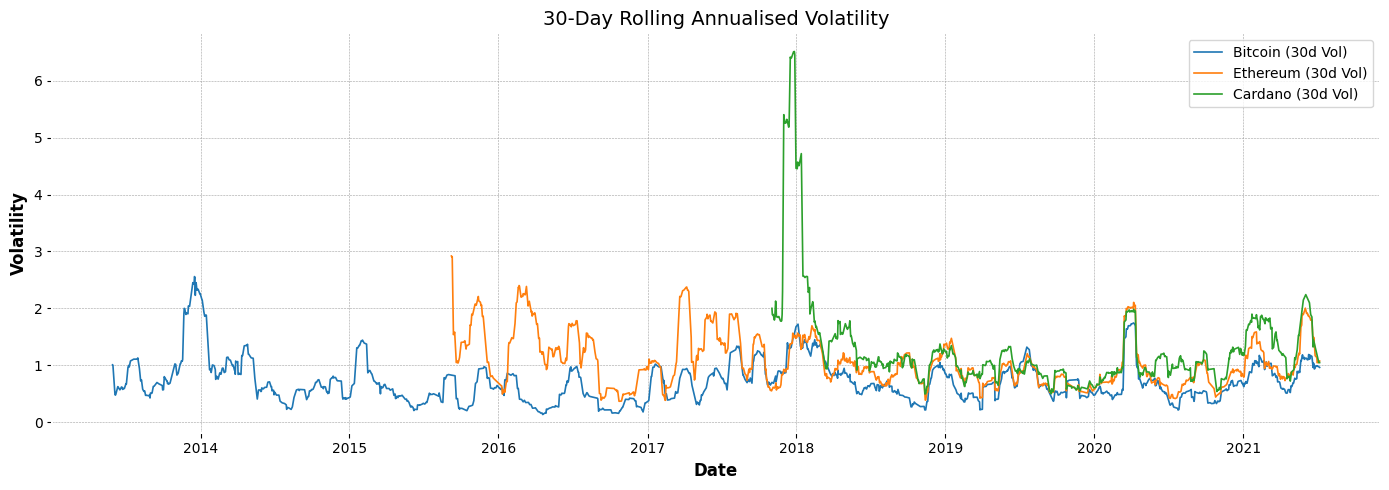

Saved: rolling volatility


In [14]:
#rolling volatility
fig, ax = plt.subplots(figsize=(14, 5))

for coin in ['Bitcoin', 'Ethereum', 'Cardano']:
    df = all_coins[all_coins['Coin'] == coin].copy()
    df.set_index('Date', inplace=True)
    df['daily_return'] = df['Close'].pct_change()#computes percentage change in price
    df['volatility_30d'] = df['daily_return'].rolling(window=30).std() * np.sqrt(365)#How much the price fluctuates over 30 days, scaled to yearly risk
    ax.plot(df.index, df['volatility_30d'], label=f'{coin} (30d Vol)', linewidth=1.2)

ax.set_title('30-Day Rolling Annualised Volatility', fontsize=14)
ax.set_ylabel('Volatility')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'rolling_volatility.png'))
plt.show()
print("Saved: rolling volatility")

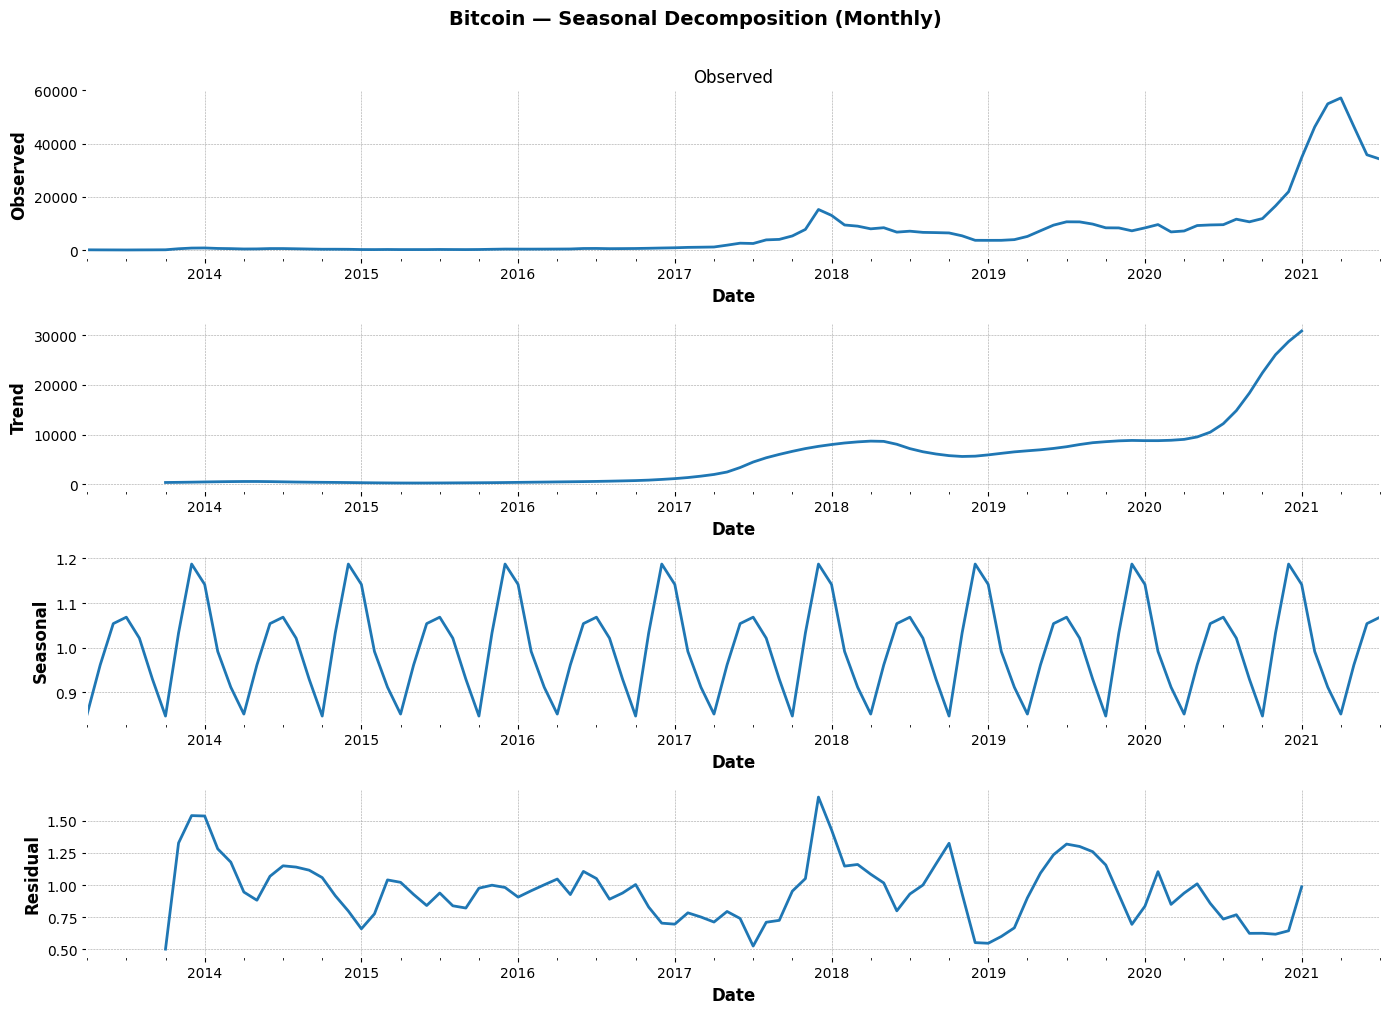

Saved: seasonal decomposition


In [16]:
#seasonal decomposition(bitcoin)
btc_monthly = btc['Close'].resample('M').mean().dropna()#convert to monthly data

decomp = seasonal_decompose(btc_monthly, model='multiplicative', period=12)#seasonal decomposition

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observed');   axes[0].set_ylabel('Observed')#org bitcoin price data
decomp.trend.plot(ax=axes[1]);                         axes[1].set_ylabel('Trend')#Shows long-term direction (growth/decline)
decomp.seasonal.plot(ax=axes[2]);                      axes[2].set_ylabel('Seasonal')#Shows repeating yearly patterns
decomp.resid.plot(ax=axes[3]);                         axes[3].set_ylabel('Residual')#Shows random fluctuations (noise)

plt.suptitle('Bitcoin — Seasonal Decomposition (Monthly)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'seasonal_decomposition_btc.png'))
plt.show()
print("Saved: seasonal decomposition")

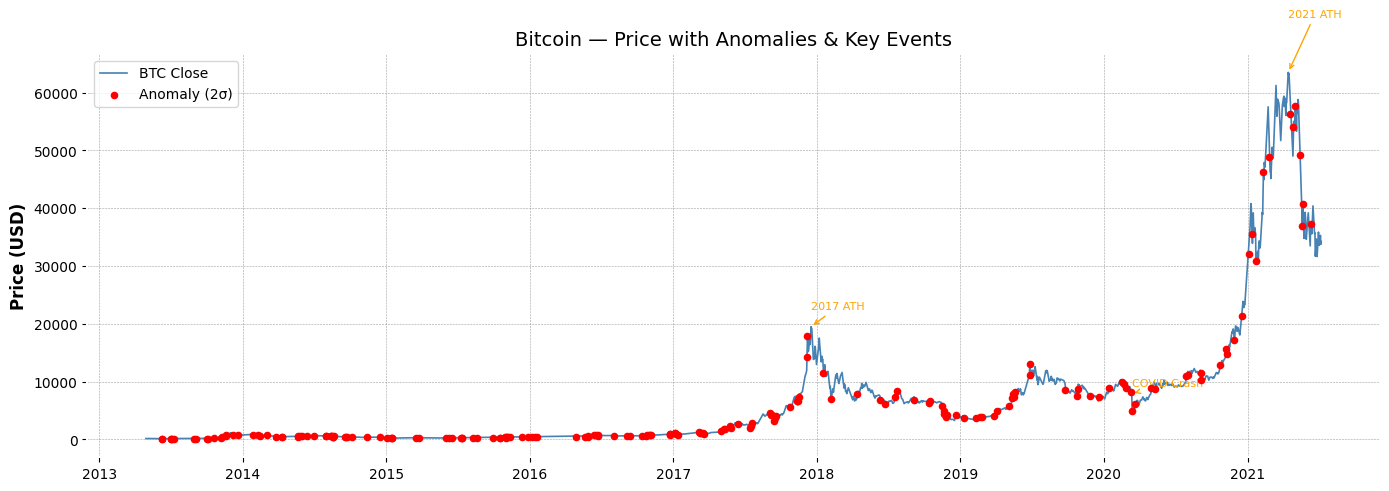

Saved: anomaly & event chart


In [18]:
#anomaly and market event detection
btc_daily = btc['Close'].copy()
btc_ret   = btc_daily.pct_change().dropna()#compute daily returns

#Flag days where return > 2 std deviations from rolling mean
rolling_mean = btc_ret.rolling(30).mean()
rolling_std  = btc_ret.rolling(30).std()
anomalies    = btc_ret[(btc_ret - rolling_mean).abs() > 2 * rolling_std]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(btc_daily.index, btc_daily, label='BTC Close', linewidth=1.2, color='steelblue')
ax.scatter(anomalies.index, btc_daily.loc[anomalies.index],
           color='red', zorder=5, s=20, label='Anomaly (2σ)')

# Annotate key market events
events = {
    '2017-12-17': '2017 ATH',
    '2020-03-12': 'COVID Crash',
    '2021-04-14': '2021 ATH',
    '2022-11-09': 'FTX Collapse'
}
for date_str, label in events.items():
    try:
        date = pd.Timestamp(date_str)
        price = btc_daily.asof(date)
        ax.annotate(label, xy=(date, price),
                    xytext=(date, price * 1.15),
                    arrowprops=dict(arrowstyle='->', color='orange'),
                    fontsize=8, color='orange')
    except:
        pass

ax.set_title('Bitcoin — Price with Anomalies & Key Events', fontsize=14)
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'anomalies_events_btc.png'))
plt.show()
print("Saved: anomaly & event chart")

In [19]:
#save processed data
all_coins.to_csv(os.path.join(PROC, 'all_coins_clean.csv'), index=False)
print("✅ Processed data saved.")

✅ Processed data saved.
